In [1]:
# Configuração
from pathlib import Path
import os
import sys
import json
import random

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/AMMCI_PRF")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)

Projeto: D:\Workspace\ws-uem\acidentes-rodoviarios-ml


# 06 — Resultados finais

## Objetivo

Comparar os resultados temporais produzidos pelo notebook 05.

Os artefatos são lidos de `outputs/metrics` e `outputs/models`; não há novo treinamento.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import tensorflow as tf
from tensorflow import keras

TARGET = "classificacao_acidente"
SEED_FOR_PLOTS = 42

CATEGORICAL_FEATURES = [
    "dia_semana", "uf", "br", "causa_acidente", "tipo_acidente",
    "fase_dia", "sentido_via", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
]

NUMERIC_FEATURES = [
    "hora", "mes", "km", "latitude", "longitude", "veiculos",
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

CLASS_NAMES = [
    "Sem Vítimas",
    "Com Vítimas Feridas",
    "Com Vítimas Fatais",
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: name for name, i in CLASS_TO_ID.items()}

temporal_runs = pd.read_csv(METRICS_DIR / "temporal_runs.csv")
temporal_summary = pd.read_csv(METRICS_DIR / "temporal_summary.csv")
m0_degradation = pd.read_csv(METRICS_DIR / "m0_degradation.csv")
mft_summary = pd.read_csv(METRICS_DIR / "mft_selection_summary.csv")
mft_history = pd.read_csv(METRICS_DIR / "mft_selection_history.csv")

predictions = pd.read_csv(
    METRICS_DIR / "d2_predictions.csv.gz",
    parse_dates=["timestamp"],
)

selection_config = json.loads(
    (MODEL_DIR / "mlp_config.json").read_text(encoding="utf-8")
)

selected_mft_config = json.loads(
    (MODEL_DIR / "selected_mft_config.json").read_text(encoding="utf-8")
)

base_config = selection_config["architecture"]

d0 = pd.read_csv(
    DATA_DIR / "d0.csv",
    sep=";",
    dtype={"br": "string"},
    parse_dates=["timestamp"],
)

d2 = pd.read_csv(
    DATA_DIR / "d2.csv",
    sep=";",
    dtype={"br": "string"},
    parse_dates=["timestamp"],
).sort_values("timestamp", kind="stable").reset_index(drop=True)

print("Resultados carregados.")

Resultados carregados.


## 1. Comparação final em D2

As quatro estratégias são comparadas pela média e pelo desvio-padrão das três seeds, com Macro-F1 como métrica principal.

,modelo,accuracy_mean,macro_precision_mean,macro_recall_mean,macro_f1_mean,macro_f1_std,mcc_mean,macro_pr_auc_mean,delta_macro_f1_vs_m0
0,M0,0.7646,0.5738,0.5570,0.5619,0.0003,0.3343,0.5780,0.0000
1,MFT,0.7701,0.5833,0.5587,0.5650,0.0013,0.3403,0.5803,0.0031
2,MRT,0.7680,0.5800,0.5577,0.5645,0.0031,0.3370,0.5821,0.0026
3,MREC,0.7697,0.5818,0.5352,0.5471,0.0004,0.3180,0.5664,-0.0148



Baseline:


,modelo,accuracy,macro_f1
0,Classe majoritária,0.775,0.2911


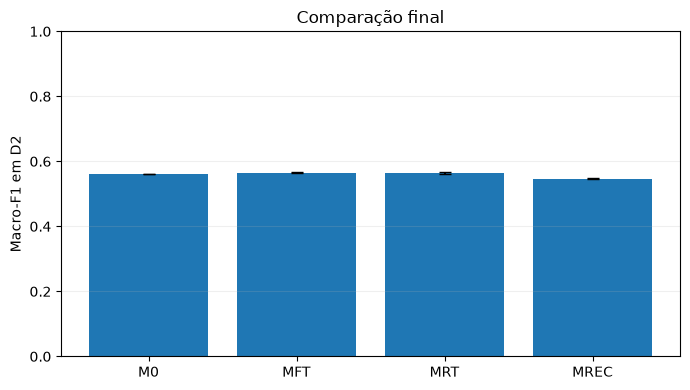

In [3]:
# Consolida uma linha por estratégia a partir das três seeds.
final_table = temporal_summary[[
    "modelo",
    "accuracy_mean",
    "macro_precision_mean",
    "macro_recall_mean",
    "macro_f1_mean",
    "macro_f1_std",
    "mcc_mean",
    "macro_pr_auc_mean",
    "delta_macro_f1_vs_m0",
]].copy()

display(final_table.round(4))

# Baseline: sempre prever a classe majoritária de D0.
majority_class = d0[TARGET].mode().iloc[0]
majority_id = CLASS_TO_ID[majority_class]

y2 = d2[TARGET].map(CLASS_TO_ID).to_numpy()
dummy_pred = np.full(len(y2), majority_id)

baseline = pd.DataFrame([{
    "modelo": "Classe majoritária",
    "accuracy": accuracy_score(y2, dummy_pred),
    "macro_f1": f1_score(
        y2,
        dummy_pred,
        labels=range(3),
        average="macro",
        zero_division=0,
    ),
}])

print("\nBaseline:")
display(baseline.round(4))

final_table.to_csv(
    METRICS_DIR / "final_comparison.csv",
    index=False,
)

# Um gráfico simples da principal métrica.
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    temporal_summary["modelo"],
    temporal_summary["macro_f1_mean"],
    yerr=temporal_summary["macro_f1_std"],
    capsize=4,
)
ax.set_ylabel("Macro-F1 em D2")
ax.set_title("Comparação final")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Degradação de M0 e efeito do fine-tuning

A comparação entre D1 e D2 quantifica a degradação do modelo histórico e o ganho incremental da atualização.

In [4]:
degradation = (
    m0_degradation
    .groupby("evaluation_set", as_index=False)
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        accuracy_mean=("accuracy", "mean"),
        macro_recall_mean=("macro_recall", "mean"),
    )
)

print("M0 ao longo do tempo:")
display(degradation.round(4))

print("\nSeleção do fine-tuning em D1:")
display(mft_summary.round(4))

paired = (
    temporal_runs[
        temporal_runs.modelo.isin(["M0", "MFT"])
    ]
    .pivot(index="seed", columns="modelo", values="macro_f1")
)

paired["delta_MFT_minus_M0"] = paired["MFT"] - paired["M0"]

print("\nDiferença MFT - M0 por seed em D2:")
display(paired.round(4))

M0 ao longo do tempo:


,evaluation_set,macro_f1_mean,macro_f1_std,accuracy_mean,macro_recall_mean
0,D1,0.5722,0.0031,0.7558,0.5694
1,D2,0.5619,0.0003,0.7646,0.5570



Seleção do fine-tuning em D1:


,modelo,macro_f1_mean,macro_f1_std
0,MFT-A,0.5530,0.0038
1,MFT-B,0.5502,0.0037



Diferença MFT - M0 por seed em D2:


modelo,M0,MFT,delta_MFT_minus_M0
seed,,,
42,0.5616,0.5655,0.0039
123,0.5620,0.5660,0.0040
2026,0.5621,0.5636,0.0015


## 3. Matrizes de confusão e métricas por classe

As matrizes usam a seed 42 apenas para visualização.
A tabela por classe resume as três seeds.

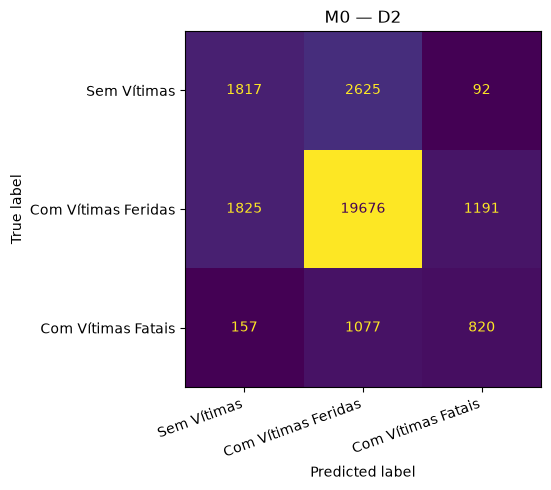

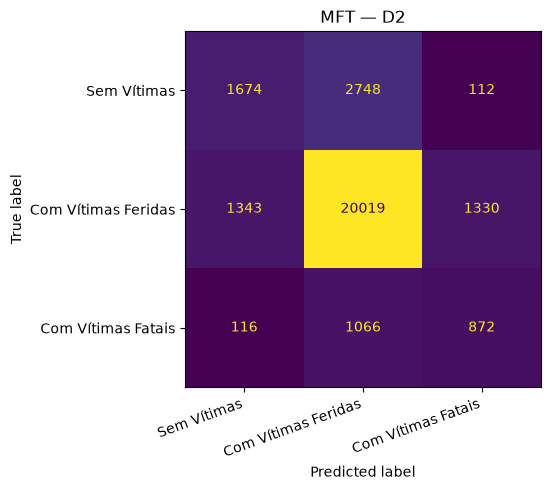

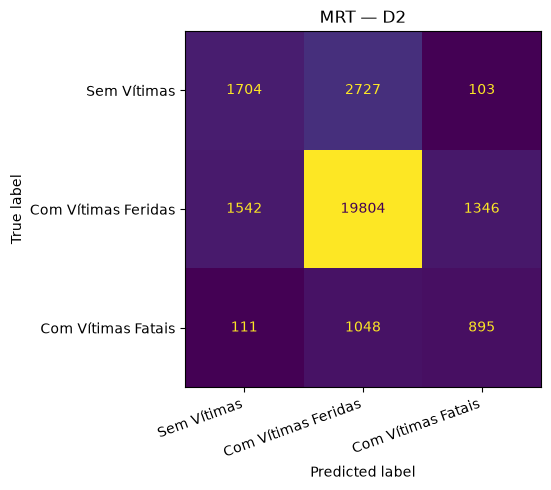

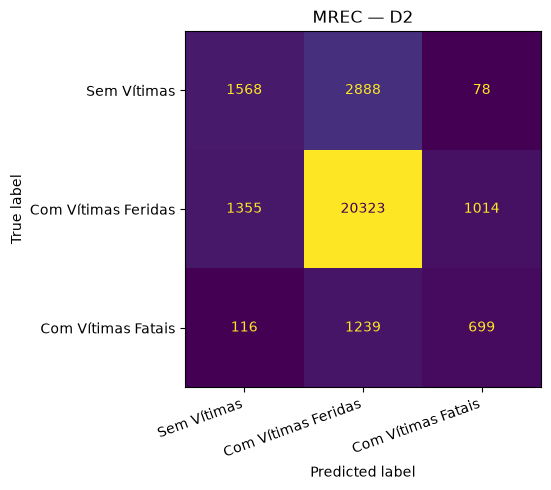

,modelo,classe,precision_mean,recall_mean,recall_std,f1_mean,f1_std
0,M0,Com Vítimas Fatais,0.3779,0.4171,0.0191,0.3961,0.0015
1,M0,Com Vítimas Feridas,0.8404,0.8727,0.0058,0.8562,0.0020
2,M0,Sem Vítimas,0.5031,0.3814,0.0168,0.4334,0.0028
3,MFT,Com Vítimas Fatais,0.3770,0.4291,0.0039,0.4014,0.0020
4,MFT,Com Vítimas Feridas,0.8394,0.8818,0.0009,0.8601,0.0007
5,MFT,Sem Vítimas,0.5335,0.3652,0.0042,0.4336,0.0046
6,MREC,Com Vítimas Fatais,0.3646,0.3900,0.0432,0.3750,0.0104
7,MREC,Com Vítimas Feridas,0.8310,0.8934,0.0041,0.8611,0.0015
8,MREC,Sem Vítimas,0.5497,0.3223,0.0223,0.4053,0.0087
9,MRT,Com Vítimas Fatais,0.3845,0.4210,0.0129,0.4018,0.0059


In [5]:
# A seed 42 é usada apenas nas figuras; as tabelas agregam todas as seeds.
for model_name in ["M0", "MFT", "MRT", "MREC"]:
    part = predictions[
        (predictions.modelo == model_name)
        & (predictions.seed == SEED_FOR_PLOTS)
    ]

    cm = confusion_matrix(
        part.y_true,
        part.y_pred,
        labels=range(3),
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES,
    ).plot(
        ax=ax,
        values_format="d",
        colorbar=False,
    )

    ax.set_title(f"{model_name} — D2")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


class_rows = []

for (model_name, seed), part in predictions.groupby(["modelo", "seed"]):
    report = classification_report(
        part.y_true,
        part.y_pred,
        labels=range(3),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    for class_name in CLASS_NAMES:
        class_rows.append({
            "modelo": model_name,
            "seed": seed,
            "classe": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1": report[class_name]["f1-score"],
        })

class_runs = pd.DataFrame(class_rows)

class_summary = (
    class_runs
    .groupby(["modelo", "classe"], as_index=False)
    .agg(
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    )
)

display(class_summary.round(4))

class_summary.to_csv(
    METRICS_DIR / "results_per_class_summary.csv",
    index=False,
)

## 4. Overfitting durante o fine-tuning

A curva abaixo é da configuração escolhida em D1 para a seed 42.
A validação foi usada somente para escolher a intensidade e o número de épocas do fine-tuning.

,epoch,loss,val_loss,val_macro_f1
3,4,0.746545,0.633054,0.553656
4,5,0.744455,0.632315,0.552736
5,6,0.741376,0.631351,0.552030
6,7,0.740035,0.631860,0.549711
7,8,0.739084,0.631809,0.552443


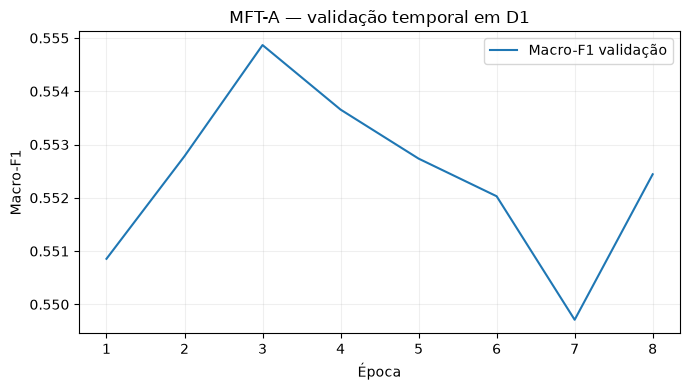

In [6]:
selected_name = selected_mft_config["name"]

curve = mft_history[
    (mft_history.modelo == selected_name)
    & (mft_history.seed == SEED_FOR_PLOTS)
].sort_values("epoch")

display(curve[[
    "epoch",
    "loss",
    "val_loss",
    "val_macro_f1",
]].tail())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.epoch, curve.val_macro_f1, label="Macro-F1 validação")
ax.set_xlabel("Época")
ax.set_ylabel("Macro-F1")
ax.set_title(f"{selected_name} — validação temporal em D1")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Permutation Importance — M0 vs. MFT

O pré-processador é reconstruído e ajustado em D0 com a mesma configuração do treinamento, garantindo compatibilidade com os pesos persistidos.

Os pesos da seed 42 foram salvos pelo notebook 05.

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def build_preprocessor():
    tracado_encoding = selection_config["preprocessing"]["tracado_encoding"]

    categories = [
        c for c in CATEGORICAL_FEATURES
        if c != "tracado_via" or tracado_encoding == "categorical"
    ]

    transformers = [
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
            ]),
            categories,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            NUMERIC_FEATURES,
        ),
    ]

    if tracado_encoding == "multihot":
        transformers.append((
            "tracado",
            CountVectorizer(
                token_pattern=r"(?u)[^;]+",
                lowercase=False,
                binary=True,
                dtype=np.float32,
            ),
            "tracado_via",
        ))

    return ColumnTransformer(transformers, sparse_threshold=1.0)


def transform_dense(preprocessor, df):
    X = preprocessor.transform(df[FEATURES])
    X = X.astype(np.float32)
    return X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=np.float32)


def build_mlp(input_dim, learning_rate, seed=42):
    set_seed(seed)

    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,))
    ])

    for units in base_config["hidden_units"]:
        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=keras.regularizers.l2(base_config["l2"]),
            )
        )

        if base_config["dropout"] > 0:
            model.add(keras.layers.Dropout(base_config["dropout"]))

    model.add(keras.layers.Dense(len(CLASS_NAMES), activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


preprocessor = build_preprocessor()
preprocessor.fit(d0[FEATURES])

sample = d2.sample(
    n=min(5000, len(d2)),
    random_state=SEED_FOR_PLOTS,
).reset_index(drop=True)

X_sample = transform_dense(preprocessor, sample)
y_sample = sample[TARGET].map(CLASS_TO_ID).to_numpy(dtype=np.int64)

m0_model = build_mlp(
    X_sample.shape[1],
    base_config["learning_rate"],
    SEED_FOR_PLOTS,
)
m0_model.load_weights(MODEL_DIR / "m0_seed_42.weights.h5")

mft_model = build_mlp(
    X_sample.shape[1],
    selected_mft_config["learning_rate"],
    SEED_FOR_PLOTS,
)
mft_model.load_weights(MODEL_DIR / "mft_seed_42.weights.h5")

print("Modelos carregados para explicabilidade.")

Modelos carregados para explicabilidade.


D:\Workspace\ws-uem\acidentes-rodoviarios-ml\.venv-scipy\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)
D:\Workspace\ws-uem\acidentes-rodoviarios-ml\.venv-scipy\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)


,feature,M0,MFT,delta_MFT_minus_M0
4,tipo_acidente,0.1386,0.1401,0.0014
3,causa_acidente,0.0557,0.0532,-0.0025
16,veiculos,0.0355,0.0414,0.0059
5,fase_dia,0.0148,0.0202,0.0053
10,uso_solo,0.0138,0.0143,0.0005
14,latitude,0.0120,0.0133,0.0013
0,dia_semana,0.0057,0.0123,0.0066
1,uf,0.0097,0.0122,0.0025
2,br,0.0058,0.0120,0.0063
9,tracado_via,0.0051,0.0115,0.0065


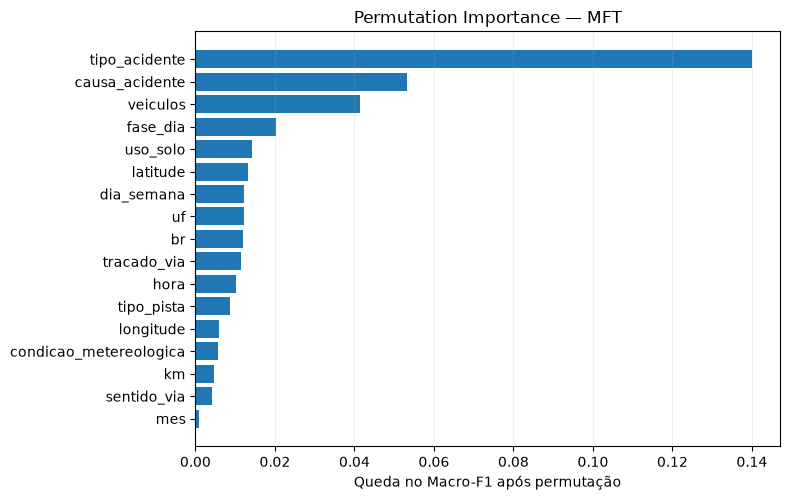

In [8]:
def macro_f1_raw(model, frame, y_true):
    X = transform_dense(preprocessor, frame)

    pred = model.predict(
        X,
        batch_size=4096,
        verbose=0,
    ).argmax(axis=1)

    return f1_score(
        y_true,
        pred,
        average="macro",
        zero_division=0,
    )


def permutation_importance_raw(model, frame, y_true, seed=42):
    rng = np.random.default_rng(seed)
    baseline = macro_f1_raw(model, frame, y_true)
    rows = []

    for feature in FEATURES:
        scores = []

        for _ in range(5):
            permuted = frame.copy()
            permuted[feature] = rng.permutation(
                permuted[feature].to_numpy()
            )

            scores.append(
                macro_f1_raw(model, permuted, y_true)
            )

        rows.append({
            "feature": feature,
            "baseline_macro_f1": baseline,
            "importance": baseline - np.mean(scores),
        })

    return pd.DataFrame(rows)


importance_m0 = permutation_importance_raw(
    m0_model,
    sample,
    y_sample,
    seed=SEED_FOR_PLOTS,
).rename(columns={"importance": "M0"})

importance_mft = permutation_importance_raw(
    mft_model,
    sample,
    y_sample,
    seed=SEED_FOR_PLOTS,
).rename(columns={"importance": "MFT"})

importance = (
    importance_m0[["feature", "M0"]]
    .merge(
        importance_mft[["feature", "MFT"]],
        on="feature",
    )
)

importance["delta_MFT_minus_M0"] = (
    importance["MFT"] - importance["M0"]
)

importance = importance.sort_values(
    "MFT",
    ascending=False,
)

display(importance.round(4))

importance.to_csv(
    METRICS_DIR / "permutation_importance_m0_mft.csv",
    index=False,
)

plot_data = importance.sort_values("MFT")

fig, ax = plt.subplots(
    figsize=(8, max(5, len(plot_data) * 0.3))
)

ax.barh(plot_data.feature, plot_data.MFT)
ax.set_xlabel("Queda no Macro-F1 após permutação")
ax.set_title("Permutation Importance — MFT")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Análise de erros

A análise identifica os pares de classes mais confundidos e apresenta exemplos representativos da seed 42.

In [9]:
representative = predictions[
    (predictions.modelo == "MFT")
    & (predictions.seed == SEED_FOR_PLOTS)
].copy()

representative["classe_real"] = representative.y_true.map(ID_TO_CLASS)
representative["classe_predita"] = representative.y_pred.map(ID_TO_CLASS)

errors = representative[
    representative.y_true != representative.y_pred
].copy()

confusion_pairs = (
    errors
    .groupby(["classe_real", "classe_predita"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
)

print("Principais confusões do MFT:")
display(confusion_pairs)

examples = (
    errors
    .groupby(["y_true", "y_pred"], group_keys=False)
    .head(2)
    .merge(
        d2.reset_index().rename(columns={"index": "row_index"}),
        on="row_index",
        how="left",
    )
)

columns = [
    "timestamp_x",
    "classe_real",
    "classe_predita",
    "causa_acidente",
    "tipo_acidente",
    "condicao_metereologica",
    "fase_dia",
    "tipo_pista",
    "uf",
    "hora",
    "mes",
    "veiculos",
]

columns = [c for c in columns if c in examples.columns]

display(examples[columns])

confusion_pairs.to_csv(
    METRICS_DIR / "results_confusion_pairs.csv",
    index=False,
)

examples[columns].to_csv(
    METRICS_DIR / "results_error_examples.csv",
    index=False,
)

Principais confusões do MFT:


,classe_real,classe_predita,size
5,Sem Vítimas,Com Vítimas Feridas,2748
3,Com Vítimas Feridas,Sem Vítimas,1343
2,Com Vítimas Feridas,Com Vítimas Fatais,1330
0,Com Vítimas Fatais,Com Vítimas Feridas,1066
1,Com Vítimas Fatais,Sem Vítimas,116
4,Sem Vítimas,Com Vítimas Fatais,112


,timestamp_x,classe_real,classe_predita,causa_acidente,tipo_acidente,condicao_metereologica,fase_dia,tipo_pista,uf,hora,mes,veiculos
0,2024-09-08 15:30:00,Sem Vítimas,Com Vítimas Feridas,Reação tardia ou ineficiente do condutor,Capotamento,Céu Claro,Pleno dia,Simples,MG,15,9,1
1,2024-09-08 15:40:00,Com Vítimas Fatais,Com Vítimas Feridas,Reação tardia ou ineficiente do condutor,Colisão com objeto,Céu Claro,Pleno dia,Simples,ES,15,9,1
2,2024-09-08 15:40:00,Com Vítimas Fatais,Com Vítimas Feridas,Acessar a via sem observar a presença dos outr...,Atropelamento de Pedestre,Céu Claro,Pleno dia,Simples,MS,15,9,2
3,2024-09-08 16:00:00,Sem Vítimas,Com Vítimas Feridas,Ausência de reação do condutor,Colisão traseira,Céu Claro,Pleno dia,Simples,GO,16,9,5
4,2024-09-08 17:00:00,Com Vítimas Feridas,Sem Vítimas,Ingestão de álcool pelo condutor,Colisão lateral sentido oposto,Céu Claro,Pleno dia,Simples,RN,17,9,2
5,2024-09-08 17:10:00,Com Vítimas Feridas,Sem Vítimas,Ingestão de álcool pelo condutor,Colisão traseira,Céu Claro,Pleno dia,Dupla,MG,17,9,1
6,2024-09-08 17:30:00,Com Vítimas Feridas,Com Vítimas Fatais,Transitar na contramão,Colisão frontal,Céu Claro,Plena Noite,Simples,CE,17,9,2
7,2024-09-08 18:00:00,Com Vítimas Feridas,Com Vítimas Fatais,Ausência de reação do condutor,Atropelamento de Pedestre,Céu Claro,Anoitecer,Dupla,PR,18,9,2
8,2024-09-09 04:33:00,Com Vítimas Fatais,Sem Vítimas,Velocidade Incompatível,Saída de leito carroçável,Ignorado,Amanhecer,Dupla,PE,4,9,1
9,2024-09-09 13:49:00,Com Vítimas Fatais,Sem Vítimas,Velocidade Incompatível,Colisão traseira,Céu Claro,Pleno dia,Dupla,PR,13,9,5


## 7. Síntese dos resultados

A síntese reúne a estratégia com maior Macro-F1 e as diferenças relevantes entre os cenários temporais.

In [10]:
best = temporal_summary.loc[
    temporal_summary.macro_f1_mean.idxmax()
]

m0 = temporal_summary[
    temporal_summary.modelo == "M0"
].iloc[0]

mft = temporal_summary[
    temporal_summary.modelo == "MFT"
].iloc[0]

fatal = class_summary[
    class_summary.classe == "Com Vítimas Fatais"
][["modelo", "recall_mean", "f1_mean"]]

print(
    f"Maior Macro-F1 médio em D2: "
    f"{best.modelo} = {best.macro_f1_mean:.4f}"
)

print(
    f"MFT - M0 em Macro-F1: "
    f"{mft.macro_f1_mean - m0.macro_f1_mean:+.4f}"
)

print("\nClasse fatal:")
display(fatal.round(4))

print(
    "\nA interpretação final deve relacionar estes resultados "
    "com o drift observado no notebook 02, sem tratar queda de "
    "desempenho isoladamente como prova de concept drift."
)

Maior Macro-F1 médio em D2: MFT = 0.5650
MFT - M0 em Macro-F1: +0.0031

Classe fatal:


,modelo,recall_mean,f1_mean
0,M0,0.4171,0.3961
3,MFT,0.4291,0.4014
6,MREC,0.3900,0.3750
9,MRT,0.4210,0.4018



A interpretação final deve relacionar estes resultados com o drift observado no notebook 02, sem tratar queda de desempenho isoladamente como prova de concept drift.


## 8. Tabela consolidada

Resultados médios em D2; **Macro-F1** é a métrica principal.

| Modelo | Dados usados | Estratégia | Accuracy | Macro-F1 | Desvio | PR-AUC | MCC | Δ Macro-F1 vs. M0 |
|---|---|---|---:|---:|---:|---:|---:|---:|
| M0 | D0 | histórico | 0.7646 | 0.5619 | 0.0003 | 0.5780 | 0.3343 | — |
| MFT | D0 → D1 | fine-tuning | 0.7701 | **0.5650** | 0.0013 | 0.5803 | 0.3403 | +0.0031 |
| MRT | D0 + D1 | retreinamento completo | 0.7680 | 0.5645 | 0.0031 | **0.5821** | 0.3370 | +0.0026 |
| MREC | D1 | somente dados recentes | 0.7697 | 0.5471 | 0.0004 | 0.5664 | 0.3180 | -0.0148 |

O baseline majoritário tem `Accuracy = 0.7750`, mas `Macro-F1 = 0.2911`.

### Tempo e complexidade

| Modelo | Tempo médio de treinamento* | Parâmetros |
|---|---:|---:|
| M0 | 11.62 s | 18.499 |
| MFT | 15.17 s | 18.499 |
| MRT | 12.03 s | 18.627 |
| MREC | 4.04 s | 17.475 |

\* Para MFT, o valor representa o custo total de obter o modelo atualizado a partir do treinamento de M0; somente a etapa adicional de fine-tuning levou aproximadamente **3.56 s** em média. A pequena diferença no número de parâmetros de MRT/MREC decorre do vocabulário categórico disponível para o pré-processamento ajustado em cada conjunto de treinamento.

## 9. Discussão

- Há **data drift**, principalmente sazonal, mas não evidência suficiente de concept drift.

- M0 perdeu `0.0103` de Macro-F1 entre D1 e D2.

- MFT superou M0 em `0.0031` de Macro-F1.

- MFT e MRT ficaram praticamente empatados; MFT teve menor custo de atualização.

- MREC foi inferior a M0, indicando utilidade dos dados históricos.

- O fine-tuning estabilizou cedo; seis épocas foram suficientes.

- `tipo_acidente` foi a variável mais importante; a classe `Com Vítimas Feridas` concentrou as principais confusões.

**Conclusão:** MFT obteve o melhor Macro-F1, mas a vantagem foi pequena.

### Limitações

2025 contém apenas janeiro, e D2 já foi observado em versões anteriores. A avaliação não é totalmente cega.